In [85]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit
import os
import sys

sys.path.append(os.path.abspath(".."))

from libs import displacement as dpm
from libs import fit_model as fm 

plt.style.use('../libs/my_style.mplstyle')

markers = ["o", "s", "v", "^", '*', 'd']
lines = ["-", "--", "-.", ":", (0, (5, 3, 1, 3, 1, 3))]

#plt.rcParams['axes.prop_cycle'] += cycler(linestyle=lines) + cycler(marker=markers)

In [89]:
scale = 0.11
interval = 10

folder = "../experiment"
path1 = f"{folder}/20251210/MC03MT4uM/beads_tracks.csv"
path2 = f"{folder}/20241114/MC03MT4uM/T2_4uM_mc03_beads_track.csv"

def get_msd(path):
    track = pd.read_csv(path)
    imsd = dpm.imsd(track, scale, interval, display=bool)
    emsd, _ = dpm.emsd(imsd, display=bool)

    return imsd, emsd

In [90]:
I1, MSD1 = get_msd(path1)
I2, MSD2 = get_msd(path2)

I2['particle'] += 10000
IMSD = pd.concat([I1, I2])

/Users/sasakinozomu/code/MTCargo_analysis/libs/displacement.py:164: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  msd_df=pd.concat([msd_df, data])
/Users/sasakinozomu/code/MTCargo_analysis/libs/displacement.py:164: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  msd_df=pd.concat([msd_df, data])


<>:11: SyntaxWarning: invalid escape sequence '\D'
<>:11: SyntaxWarning: invalid escape sequence '\D'
/var/folders/bq/xf1f11f12mb4mkksc249kx6w0000gn/T/ipykernel_12626/1824614035.py:11: SyntaxWarning: invalid escape sequence '\D'
  xlabel='lag time $\Delta$ [s]',


[(8.0, 500.0),
 (0.001, 10000.0),
 None,
 None,
 Text(0.5, 0, 'lag time $\\Delta$ [s]'),
 Text(0, 0.5, 'MSD $\\langle \\Delta r^2 \\rangle$ $[μm^2]$')]

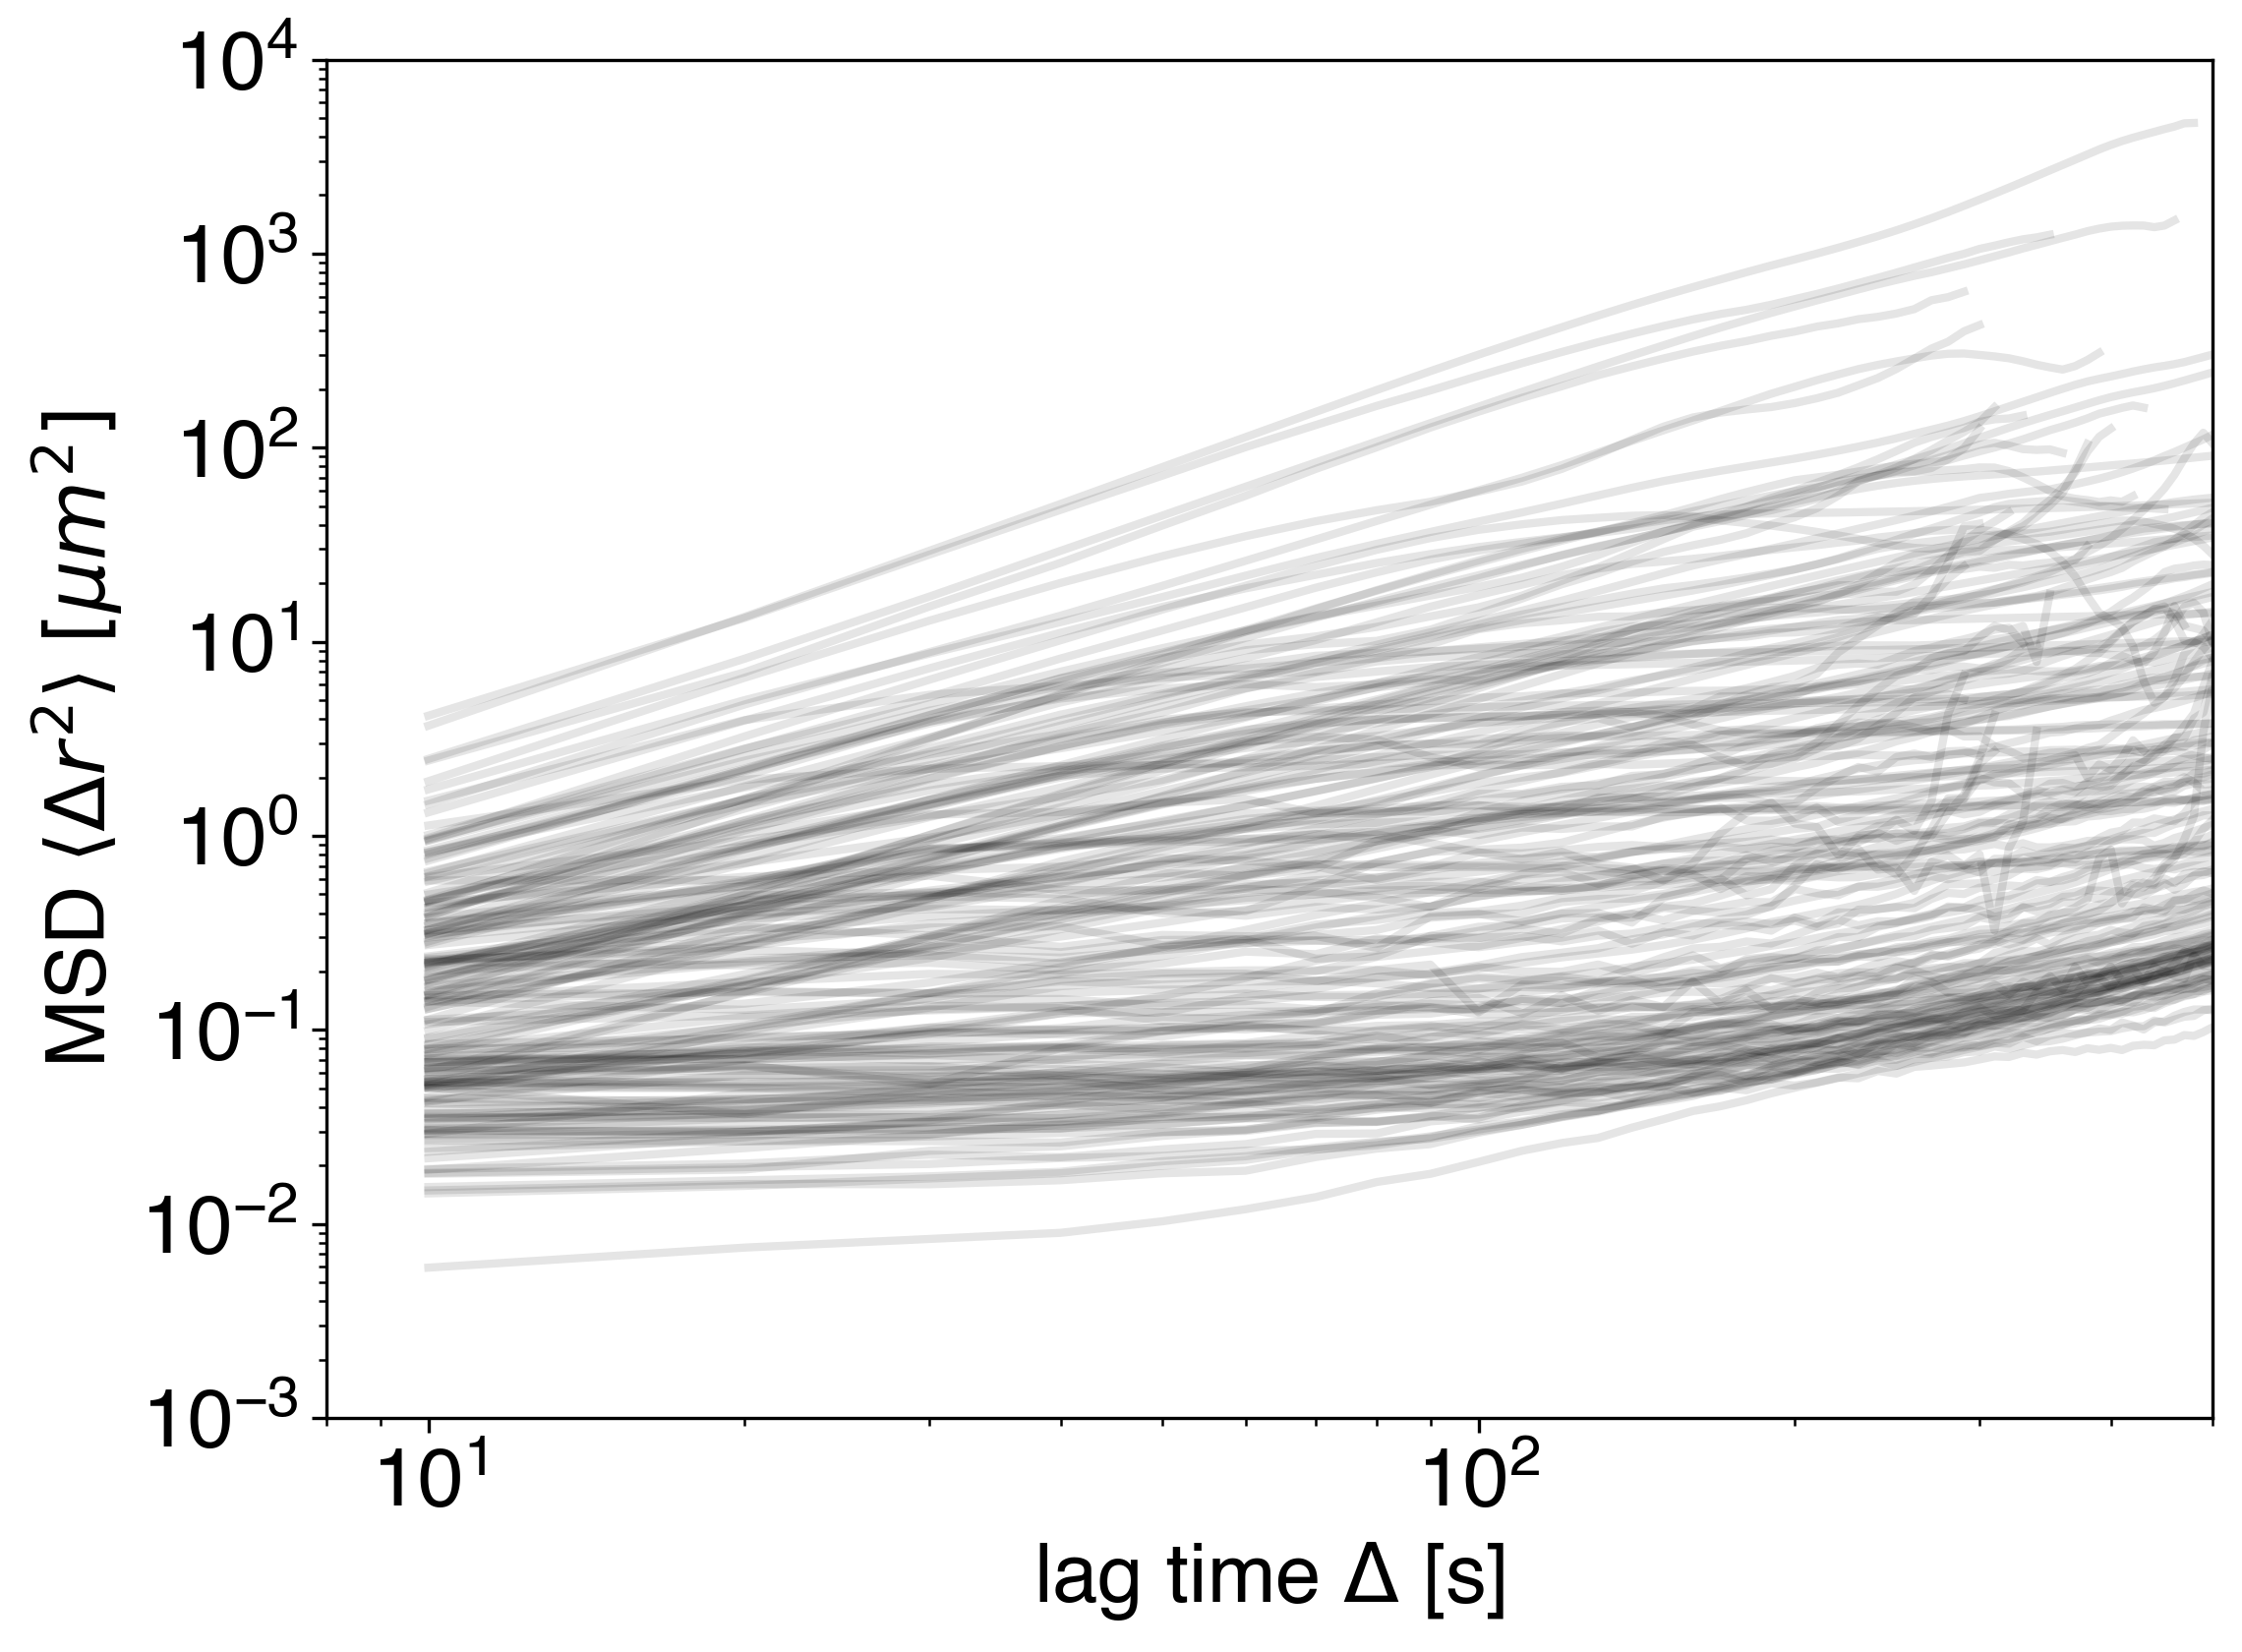

In [91]:
fig, ax = plt.subplots()

for _, p in IMSD.groupby('particle'):
    ax.plot(p['lag time'], p['MSD'], color = 'black', alpha = 0.1)

ax.set(
    xlim=(0.8*1e1, 5*1e2),
    ylim=(1e-3, 1e4),
    xscale='log',
    yscale='log',
    xlabel='lag time $\Delta$ [s]',
    ylabel='MSD $\\langle \\Delta r^2 \\rangle$ $[\u03bcm^2]$'
    )

<>:13: SyntaxWarning: invalid escape sequence '\p'
<>:14: SyntaxWarning: invalid escape sequence '\p'
<>:27: SyntaxWarning: invalid escape sequence '\D'
<>:13: SyntaxWarning: invalid escape sequence '\p'
<>:14: SyntaxWarning: invalid escape sequence '\p'
<>:27: SyntaxWarning: invalid escape sequence '\D'
/var/folders/bq/xf1f11f12mb4mkksc249kx6w0000gn/T/ipykernel_12626/2272911032.py:13: SyntaxWarning: invalid escape sequence '\p'
  ax.text(70, 5e1, '$\propto \Delta ^{2.0}$')
/var/folders/bq/xf1f11f12mb4mkksc249kx6w0000gn/T/ipykernel_12626/2272911032.py:14: SyntaxWarning: invalid escape sequence '\p'
  ax.text(120, 0.4*1e1, '$\propto \Delta ^{1.0}$')
/var/folders/bq/xf1f11f12mb4mkksc249kx6w0000gn/T/ipykernel_12626/2272911032.py:27: SyntaxWarning: invalid escape sequence '\D'
  xlabel='lag time $\Delta$ [s]',


[(8.0, 500.0),
 (0.1, 100.0),
 None,
 None,
 Text(0.5, 0, 'lag time $\\Delta$ [s]'),
 Text(0, 0.5, 'MSD $\\langle \\Delta r^2 \\rangle$ $[μm^2]$')]

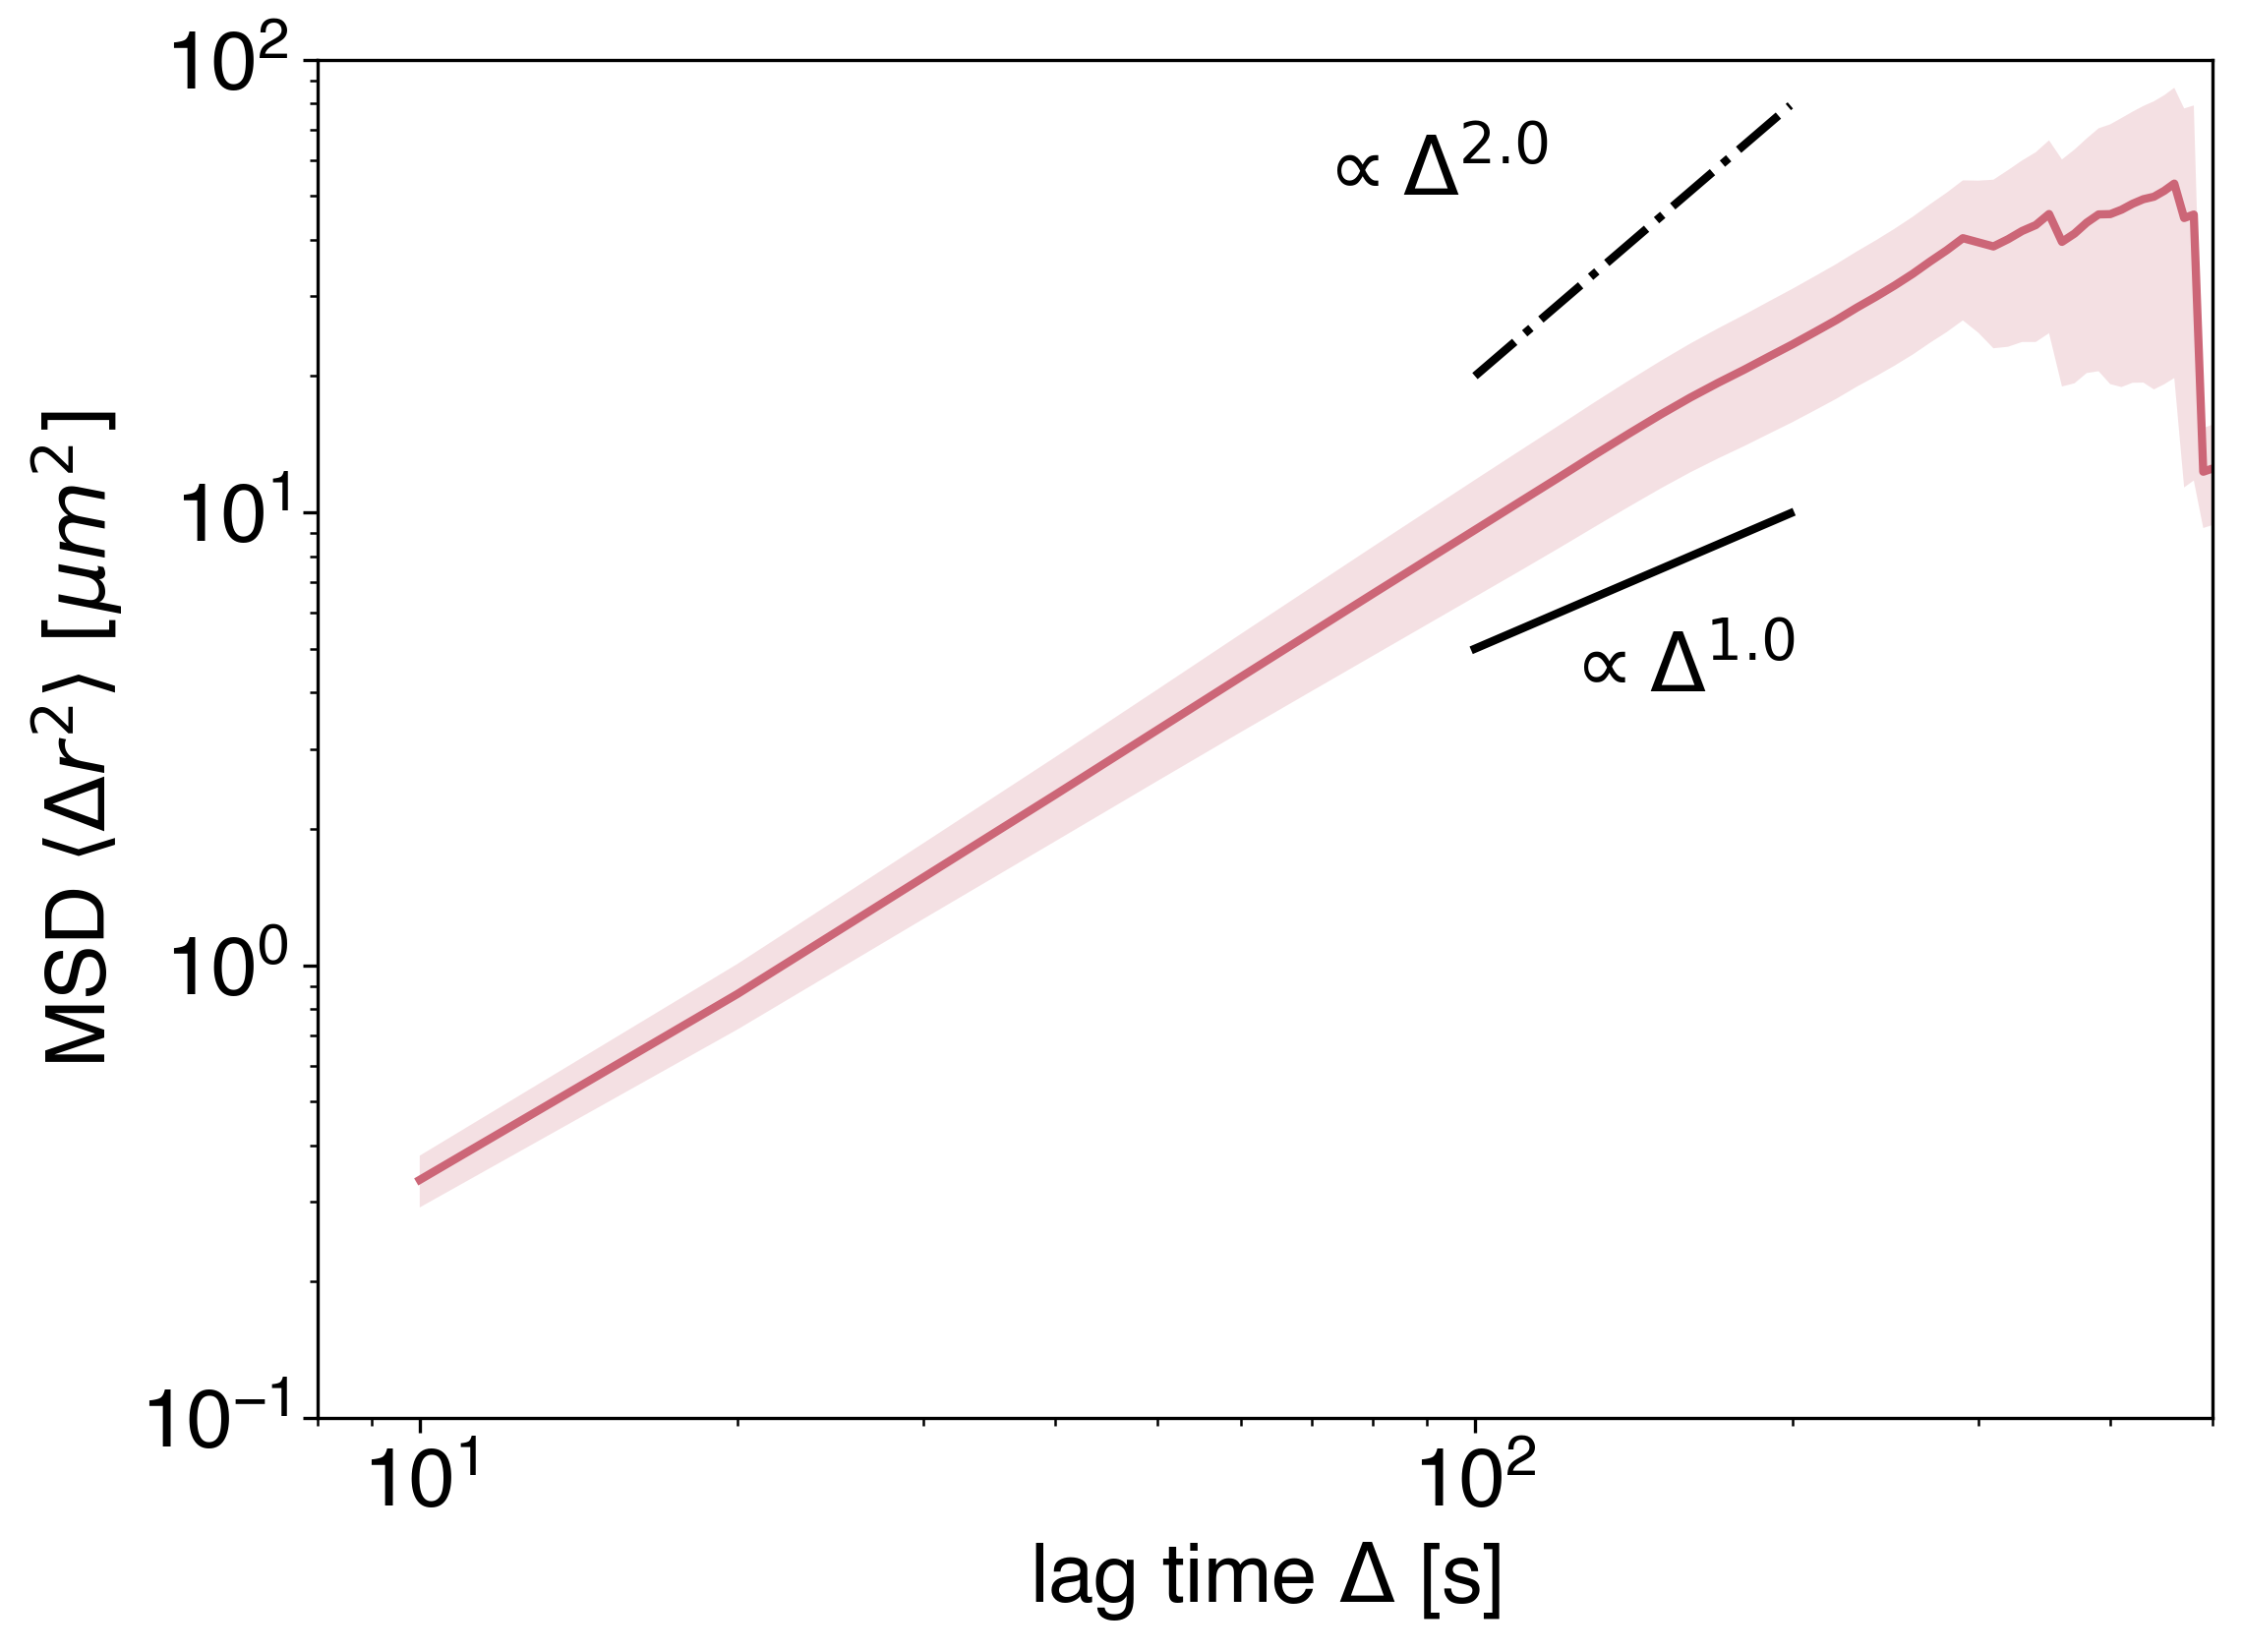

In [92]:
emsd = IMSD.groupby("lag time").mean()
emsd_err = IMSD.groupby("lag time").sem()['MSD'].to_numpy()

fig, ax = plt.subplots()
ty = np.arange(100, 200)

y2 = 2.0e-3 * ty ** 2.0
y3 = 0.05 * ty ** 1.0

ax.plot(ty, y2, c = 'black', linestyle = '-.')
ax.plot(ty, y3, c = 'black', linestyle = '-')

ax.text(70, 5e1, '$\propto \Delta ^{2.0}$')
ax.text(120, 0.4*1e1, '$\propto \Delta ^{1.0}$')

ax.plot(emsd.index, emsd['MSD'])
ax.fill_between(emsd.index,
                emsd['MSD'] - emsd_err,
                emsd['MSD'] + emsd_err,
                alpha=0.2)

ax.set(
    xlim=(0.8*1e1, 5*1e2),
    ylim=(1e-1, 1e2),
    xscale='log',
    yscale='log',
    xlabel='lag time $\Delta$ [s]',
    ylabel='MSD $\\langle \\Delta r^2 \\rangle$ $[\u03bcm^2]$'
    )